In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:\\Users\\HP\\OneDrive\\Documents\\DataMites\\Machine learning\\main_data.csv')
df

,Unnamed: 0,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
0,0,AFG,33.70269,34.53602,34.53602
1,1,AGO,64.57157,65.32993,64.99177
2,2,ALB,52.60171,52.67715,52.64734
3,3,ARE,86.51006,89.75407,86.52729
4,4,ARG,48.96341,56.44015,49.26822
...,...,...,...,...,...
186,186,XKX,50.29844,55.28702,52.87432
187,187,YEM,0.00000,0.00000,0.00000
188,188,ZAF,68.26741,68.32331,68.24925
189,189,ZMB,71.10859,72.09460,71.72488


In [3]:
df.head()

,Unnamed: 0,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
0,0,AFG,33.70269,34.53602,34.53602
1,1,AGO,64.57157,65.32993,64.99177
2,2,ALB,52.60171,52.67715,52.64734
3,3,ARE,86.51006,89.75407,86.52729
4,4,ARG,48.96341,56.44015,49.26822


In [4]:
df.tail()

,Unnamed: 0,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
186,186,XKX,50.29844,55.28702,52.87432
187,187,YEM,0.00000,0.00000,0.00000
188,188,ZAF,68.26741,68.32331,68.24925
189,189,ZMB,71.10859,72.09460,71.72488
190,190,ZWE,46.39289,60.00173,48.55427


In [5]:
df.describe()

,Unnamed: 0,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
count,191.0000,191.000000,191.000000,191.000000
mean,95.0000,63.269214,65.845667,64.770344
std,55.2811,16.622900,15.815424,15.707923
min,0.0000,0.000000,0.000000,0.000000
25%,47.5000,56.300935,59.640150,57.710025
50%,95.0000,66.694200,68.683240,67.943670
75%,142.5000,73.407800,75.182955,73.913715
max,190.0000,91.210020,93.467020,91.241050


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 191 non-null    int64  
 1   country                                    191 non-null    object 
 2   fy2017, Dealing with construction permits  191 non-null    float64
 3   fy2019, Dealing with construction permits  191 non-null    float64
 4   fy2018, Dealing with construction permits  191 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 7.6+ KB


In [7]:
for i in df.columns:
  print(i)

Unnamed: 0
country
fy2017, Dealing with construction permits
fy2019, Dealing with construction permits
fy2018, Dealing with construction permits


In [8]:
df.isna().sum()

Unnamed: 0                                   0
country                                      0
fy2017, Dealing with construction permits    0
fy2019, Dealing with construction permits    0
fy2018, Dealing with construction permits    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(191, 5)

In [14]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [15]:
df.head()

,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
0,AFG,33.70269,34.53602,34.53602
1,AGO,64.57157,65.32993,64.99177
2,ALB,52.60171,52.67715,52.64734
3,ARE,86.51006,89.75407,86.52729
4,ARG,48.96341,56.44015,49.26822


In [16]:
x = df.drop('country',axis=1)
x.head()

,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits"
0,33.70269,34.53602,34.53602
1,64.57157,65.32993,64.99177
2,52.60171,52.67715,52.64734
3,86.51006,89.75407,86.52729
4,48.96341,56.44015,49.26822


In [17]:
from sklearn.cluster import KMeans

sse = []
for i in range(1,12):
  kmeans = KMeans(n_clusters= i)
  kmeans.fit(x)
  sse.append(kmeans.inertia_)  # Inertia=∑(distance from point to centroid)2
sse

[146905.57870299436,
 75382.42814728087,
 33781.051375450064,
 21605.784861370328,
 15204.778614873434,
 10984.44008561344,
 10547.476128247301,
 6812.772141270339,
 5438.325964031863,
 3856.2260325528932,
 3227.7316196058982]

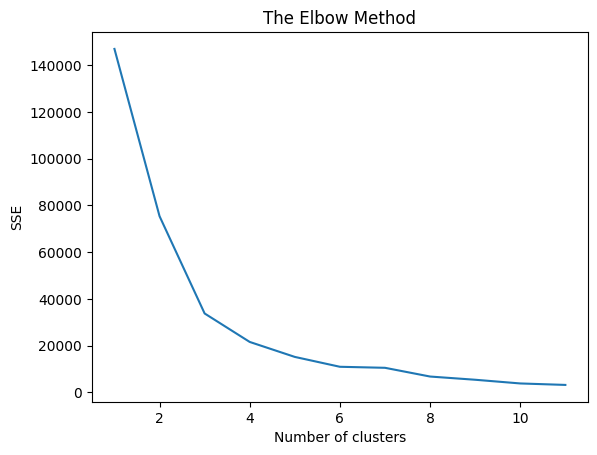

In [18]:
plt.plot(range(1,12),sse)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [19]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4)
model.fit(x)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [22]:
model.inertia_

24086.577133225735

In [23]:
labels = model.labels_
labels

array([1, 3, 3, 0, 3, 0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 1, 0, 3, 3,
       3, 3, 0, 0, 0, 1, 0, 0, 0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 3, 3, 0, 0,
       0, 0, 0, 3, 3, 0, 2, 0, 0, 3, 0, 0, 0, 3, 3, 0, 0, 3, 3, 3, 1, 3,
       0, 3, 3, 3, 0, 3, 3, 1, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 3,
       0, 1, 3, 0, 0, 3, 0, 3, 1, 2, 0, 3, 0, 3, 0, 0, 0, 0, 3, 1, 0, 0,
       0, 0, 3, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0, 1, 3, 1, 0, 0, 3, 0, 0, 3,
       0, 0, 0, 3, 3, 0, 3, 0, 0, 3, 0, 3, 0, 0, 0, 3, 3, 0, 1, 1, 3, 0,
       2, 0, 1, 3, 3, 3, 3, 0, 0, 3, 2, 1, 3, 0, 3, 3, 0, 3, 0, 0, 0, 3,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 2, 0, 0, 3], dtype=int32)

In [24]:
model.cluster_centers_

# The values represent the centroid (average) of each feature within that cluster.
# feature 1 , 2 ,3

array([[74.35805111, 75.6272696 , 74.94417747],
       [40.76217786, 42.29737143, 41.93777929],
       [ 0.        ,  0.        ,  0.        ],
       [56.88085329, 61.60629342, 59.78812603]])

In [25]:
df['labels'] = labels
df

,country,"fy2017, Dealing with construction permits","fy2019, Dealing with construction permits","fy2018, Dealing with construction permits",labels
0,AFG,33.70269,34.53602,34.53602,1
1,AGO,64.57157,65.32993,64.99177,3
2,ALB,52.60171,52.67715,52.64734,3
3,ARE,86.51006,89.75407,86.52729,0
4,ARG,48.96341,56.44015,49.26822,3
...,...,...,...,...,...
186,XKX,50.29844,55.28702,52.87432,3
187,YEM,0.00000,0.00000,0.00000,2
188,ZAF,68.26741,68.32331,68.24925,0
189,ZMB,71.10859,72.09460,71.72488,0
